In [1]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
f = uproot.open("build/run0.root")
print(f.keys())

['phsp_head;1', 'phsp_plane_000;1', 'phsp_plane_001;1', 'phsp_plane_002;1', 'phsp_plane_003;1', 'phsp_plane_004;1', 'phsp_plane_005;1', 'phsp_plane_006;1', 'phsp_plane_007;1', 'phsp_plane_008;1', 'phsp_plane_009;1', 'phsp_plane_010;1', 'phsp_plane_011;1', 'phsp_plane_012;1', 'phsp_plane_013;1', 'phsp_plane_014;1', 'phsp_plane_015;1', 'phsp_plane_016;1', 'phsp_plane_017;1', 'phsp_plane_018;1', 'phsp_plane_019;1', 'phsp_plane_020;1', 'phsp_plane_021;1', 'phsp_plane_022;1', 'phsp_plane_023;1', 'phsp_plane_024;1', 'phsp_plane_025;1', 'phsp_plane_026;1', 'phsp_plane_027;1', 'phsp_plane_028;1', 'phsp_plane_029;1', 'phsp_plane_030;1', 'phsp_plane_031;1', 'phsp_plane_032;1', 'phsp_plane_033;1', 'phsp_plane_034;1', 'phsp_plane_035;1', 'phsp_plane_036;1', 'phsp_plane_037;1', 'phsp_plane_038;1', 'phsp_plane_039;1', 'phsp_plane_040;1', 'phsp_plane_041;1', 'phsp_plane_042;1', 'phsp_plane_043;1', 'phsp_plane_044;1', 'phsp_plane_045;1', 'phsp_plane_046;1', 'phsp_plane_047;1', 'phsp_plane_048;1', 'phs

In [39]:
tree_head = f["phsp_head;1"]
tree_head.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
x                    | double                   | AsDtype('>f8')
y                    | double                   | AsDtype('>f8')
z                    | double                   | AsDtype('>f8')
u                    | double                   | AsDtype('>f8')
v                    | double                   | AsDtype('>f8')
w                    | double                   | AsDtype('>f8')
kE                   | double                   | AsDtype('>f8')
weight               | double                   | AsDtype('>f8')
pdg                  | int32_t                  | AsDtype('>i4')


In [ ]:
n_planes = len(f.keys()) - 1
depth  = np.arange(.5, n_planes + .5, 1.)
dd = np.zeros(n_planes)
for i in range(n_planes):
    tree = f[f"phsp_plane_{i:03d};1"]
    kE = tree['kE'].array(library="np")
    weight = tree['weight'].array(library="np")
    dd[i] = np.sum(kE * weight)
pdd = dd/dd.max()
print(f"dmax = {depth[np.argmax(pdd[::-1])]} mm")


dmax = 0.5 mm


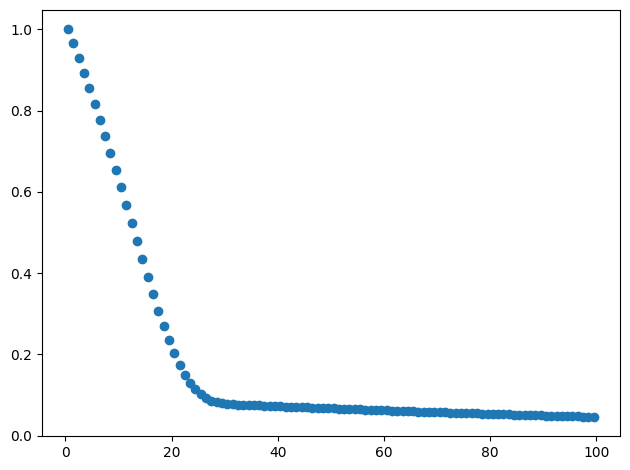

In [ ]:
plt.plot(depth, pdd[::-1], 'o')
plt.tight_layout()